# Filtros de Algebra Lineal en Imagenes

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
image_path = "/content/burger-wallpaper.png"

In [3]:
try:
    img = Image.open(image_path).convert("L")  # L = escala de grises
    F_original = np.array(img, dtype=np.uint8)
except (FileNotFoundError, OSError) as e:
    print(f"No se pudo cargar la imagen: {e}")
    print("Usando imagen de prueba (degradado 256×256).")
    x, y = np.meshgrid(np.arange(256), np.arange(256))
    F_original = ((x + y) // 2).astype(np.uint8)

No se pudo cargar la imagen: [Errno 2] No such file or directory: '/content/burger-wallpaper.png'
Usando imagen de prueba (degradado 256×256).


In [ ]:
F = F_original.astype(np.float64)
L = 256

# ─── 1. NEGATIVO ─────────────────────────────────────────
G_negativo = (L - 1) - F

# ─── 2. AJUSTE DE BRILLO ─────────────────────────────────
c_brillo = 60
G_brillante = F + c_brillo
G_oscuro    = F - c_brillo

# ─── 3. AJUSTE DE CONTRASTE (stretch) ────────────────────
G_contraste = (F - F.min()) / (F.max() - F.min()) * 255

# ─── 4. UMBRALIZACIÓN (Thresholding) ─────────────────────
T = 150
G_umbral = np.where(F >= T, 255.0, 0.0)

# ─── 5. GAMMA CORRECTION ─────────────────────────────────
gamma = 0.5
G_gamma = 255.0 * (F / 255.0) ** gamma

# ─── Clipping: mantener en [0, 255] ──────────────────────
def clip_uint8(x):
    return np.clip(x, 0, 255).astype(np.uint8)

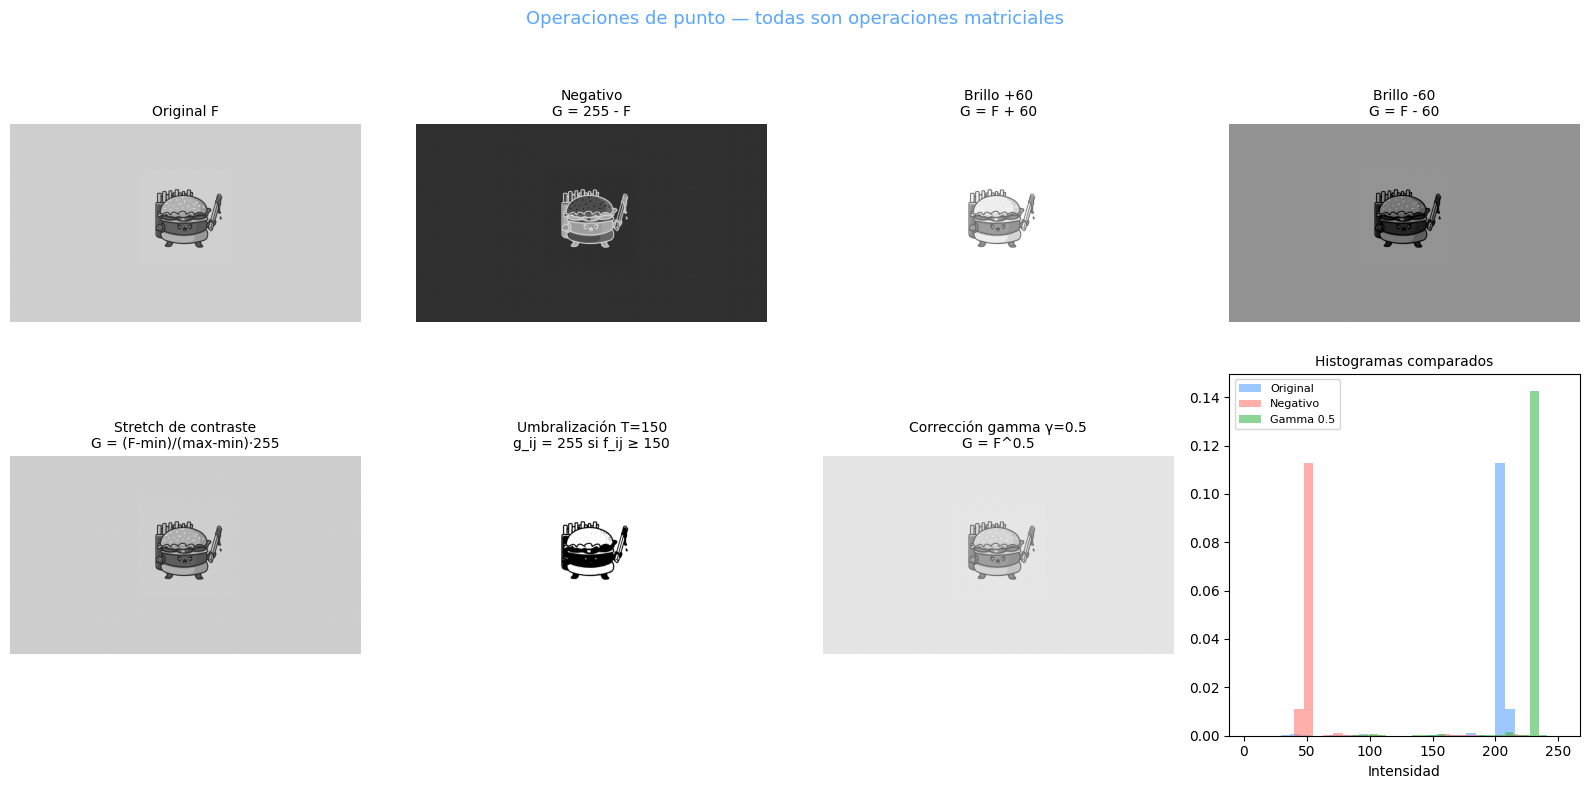

In [ ]:
resultados = [
    (F_original,              'Original F'),
    (clip_uint8(G_negativo),  f'Negativo\nG = 255 - F'),
    (clip_uint8(G_brillante), f'Brillo +{c_brillo}\nG = F + {c_brillo}'),
    (clip_uint8(G_oscuro),    f'Brillo -{c_brillo}\nG = F - {c_brillo}'),
    (clip_uint8(G_contraste), 'Stretch de contraste\nG = (F-min)/(max-min)·255'),
    (clip_uint8(G_umbral),    f'Umbralización T={T}\ng_ij = 255 si f_ij ≥ {T}'),
    (clip_uint8(G_gamma),     f'Corrección gamma γ={gamma}\nG = F^{gamma}'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (img, titulo) in enumerate(resultados):
    axes[i].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[i].set_title(titulo, fontsize=10)
    axes[i].axis('off')

ax_hist = axes[7]
ax_hist.hist(F.ravel(), bins=32, alpha=0.6, color='#58a6ff', label='Original', density=True)
ax_hist.hist(G_negativo.ravel(), bins=32, alpha=0.6, color='#ff7b72', label='Negativo', density=True)
ax_hist.hist(G_gamma.ravel(), bins=32, alpha=0.6, color='#3fb950', label=f'Gamma {gamma}', density=True)
ax_hist.set_title('Histogramas comparados', fontsize=10)
ax_hist.set_xlabel('Intensidad')
ax_hist.legend(fontsize=8)

plt.suptitle('Operaciones de punto — todas son operaciones matriciales',
             fontsize=13, color='#58a6ff')
plt.tight_layout()
plt.show()